<a href="https://colab.research.google.com/github/Jeevansomavarapu/ML_Project1/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv('kidney_disease.csv')
columns=pd.read_csv('data_description.txt',sep='-')
columns=columns.reset_index()
columns.columns=['cols','abb_col_names']
df.columns = columns.abb_col_names.values

In [59]:
df.shape

(400, 26)

In [60]:
pd.read_csv('data_description.txt')

,1. Features:
0,id -id
1,age -age
2,bp -blood pressure
3,sg -specific gravity
4,al -albumin
5,su -sugar
6,rbc -red blood cells
7,pc - pus cell
8,pcc -pus cell clumps
9,ba -bacteria


In [61]:
columns=pd.read_csv('data_description.txt',sep='-')
columns=columns.reset_index()
columns.columns=['cols','abb_col_names']

In [62]:
columns

,cols,abb_col_names
0,id,id
1,age,age
2,bp,blood pressure
3,sg,specific gravity
4,al,albumin
5,su,sugar
6,rbc,red blood cells
7,pc,pus cell
8,pcc,pus cell clumps
9,ba,bacteria


In [63]:
df.head()

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,ypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [64]:
df.columns = columns.abb_col_names.values
df

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,ypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [65]:
df.dtypes

,0
id,int64
age,float64
blood pressure,float64
specific gravity,float64
albumin,float64
sugar,float64
red blood cells,object
pus cell,object
pus cell clumps,object
bacteria,object


In [66]:
###As it can be seen, red_blood_cell_count, packed_cell_volume and white_blood_cell_count are object type. We need to
#change to numerical dtype.

In [67]:
# The 'red blood cells' column (the categorical one) should NOT be in this list.
# The 'red blood cell count' (the numerical one) should be.
features_to_convert_to_numeric = ['packed cell volume','white blood cell count','red blood cell count']

In [68]:
def convert_dtype(df,feature):
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

In [69]:
for feature_col in features_to_convert_to_numeric:
    convert_dtype(df, feature_col)

In [70]:
df.dtypes

,0
id,int64
age,float64
blood pressure,float64
specific gravity,float64
albumin,float64
sugar,float64
red blood cells,object
pus cell,object
pus cell clumps,object
bacteria,object


In [71]:
def extract_cat_num(df):
    cat_col=[col for col in df.columns if df[col].dtype=='object']
    num_col=[col for col in df.columns if df[col].dtype!='object']
    return cat_col,num_col

In [72]:
cat_col,num_col=extract_cat_num(df)

In [73]:
cat_col

['red blood cells',
 ' pus cell',
 'pus cell clumps',
 'bacteria',
 'ypertension',
 'diabetes mellitus',
 'coronary artery disease',
 'appetite',
 'pedal edema',
 'anemia',
 'class']

In [74]:
num_col

['id',
 'age',
 'blood pressure',
 'specific gravity',
 'albumin',
 'sugar',
 'blood glucose random',
 'blood urea',
 'serum creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed cell volume',
 'white blood cell count',
 'red blood cell count']

In [75]:
### total unique categories in our categorical features to check if any dirtiness in data or not

In [76]:
for col in cat_col:
    print('{} has {} values '.format(col,df[col].unique()))
    print('\n')

red blood cells has [nan 'normal' 'abnormal'] values 


 pus cell has ['normal' 'abnormal' nan] values 


pus cell clumps has ['notpresent' 'present' nan] values 


bacteria has ['notpresent' 'present' nan] values 


ypertension has ['yes' 'no' nan] values 


diabetes mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values 


coronary artery disease has ['no' 'yes' '\tno' nan] values 


appetite has ['good' 'poor' nan] values 


pedal edema has ['no' 'yes' nan] values 


anemia has ['no' 'yes' nan] values 


class has ['ckd' 'ckd\t' 'notckd'] values 




In [77]:
# These lines are for cleaning categorical values, not type conversion.
df['diabetes mellitus'] = df['diabetes mellitus'].replace(to_replace = {'\tno':'no','\tyes':'yes',' yes':'yes'})
df['coronary artery disease'] = df['coronary artery disease'].replace(to_replace = '\tno', value='no')
df['class'] = df['class'].replace(to_replace = 'ckd\t', value = 'ckd')

In [78]:
for col in cat_col:
    print('{} has {} values '.format(col,df[col].unique()))
    print('\n')

red blood cells has [nan 'normal' 'abnormal'] values 


 pus cell has ['normal' 'abnormal' nan] values 


pus cell clumps has ['notpresent' 'present' nan] values 


bacteria has ['notpresent' 'present' nan] values 


ypertension has ['yes' 'no' nan] values 


diabetes mellitus has ['yes' 'no' nan] values 


coronary artery disease has ['no' 'yes' nan] values 


appetite has ['good' 'poor' nan] values 


pedal edema has ['no' 'yes' nan] values 


anemia has ['no' 'yes' nan] values 


class has ['ckd' 'notckd'] values 




In [79]:
##Looks good now apart from the NaNs



In [80]:
len(num_col)

15

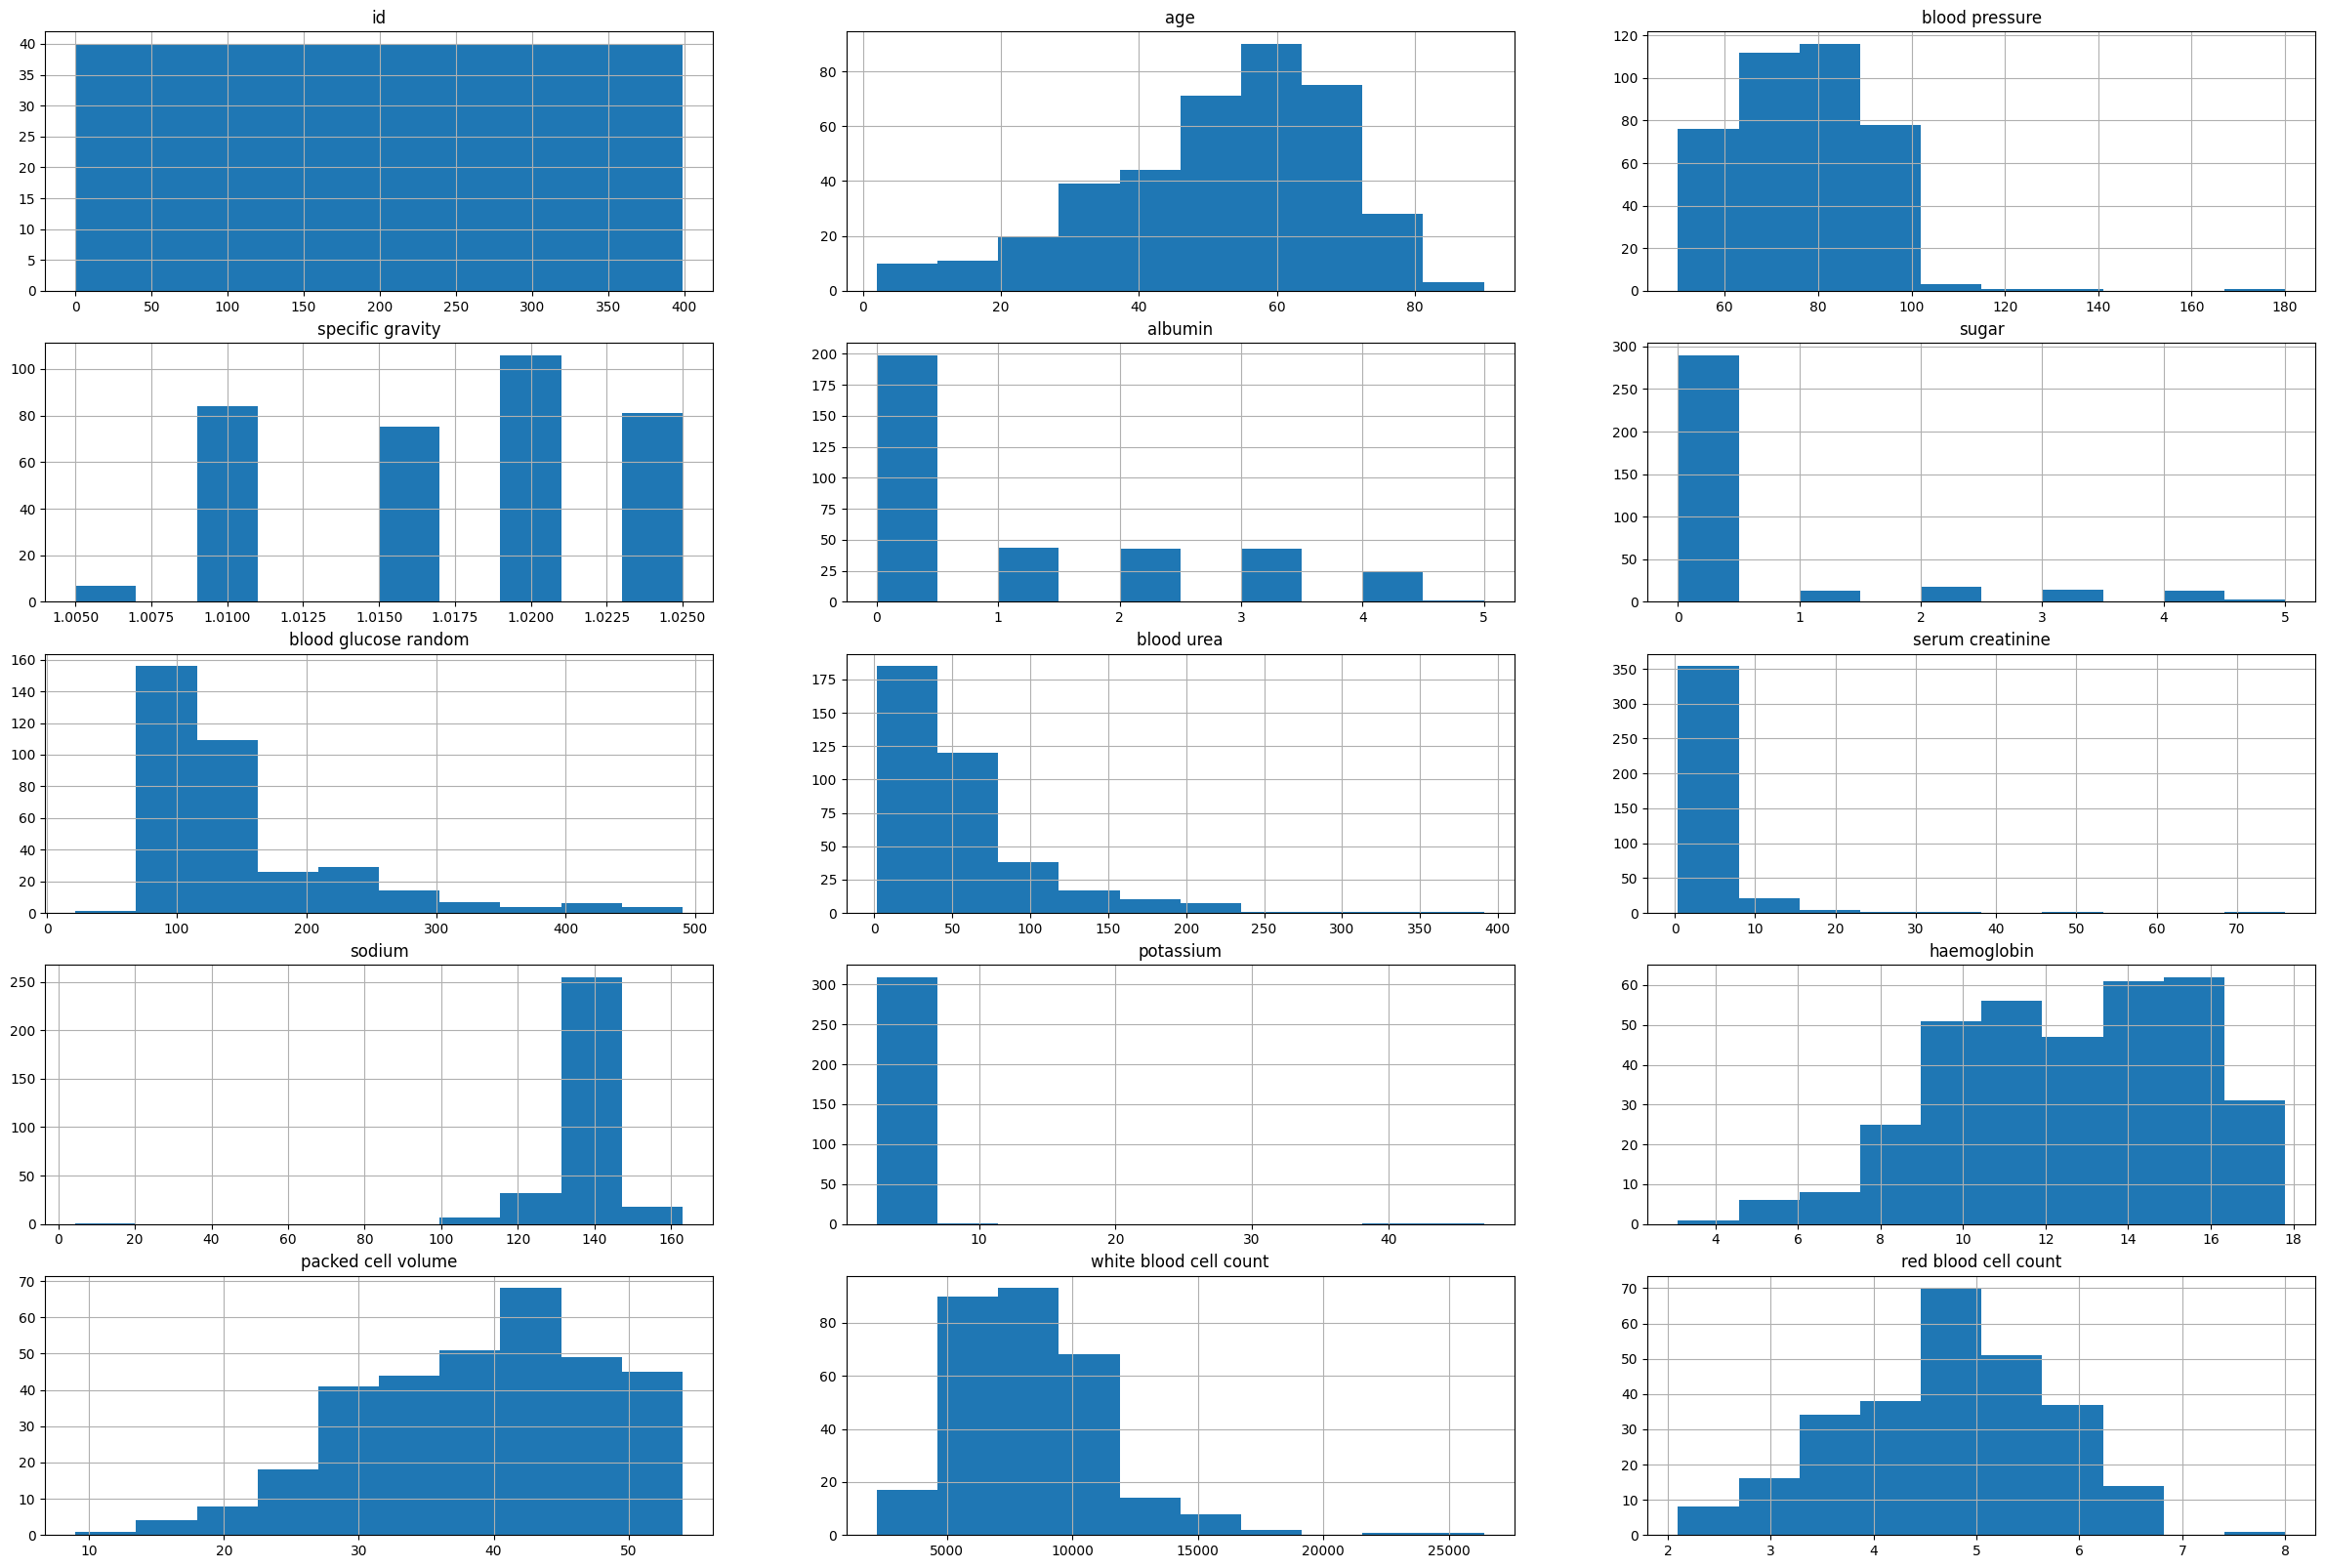

In [81]:
plt.figure(figsize=(30,20))
for i,feature in enumerate(num_col):
    plt.subplot(5,3,i+1)
    df[feature].hist()
    plt.title(feature)

In [82]:
#Observations:
   # 1.age looks a bit left skewed
    #2.Blood gluscose random is right skewed
    #3.Blood Urea is also a bit right skewed
    #4.Rest of the features are lightly skewed


In [83]:
len(cat_col)

11

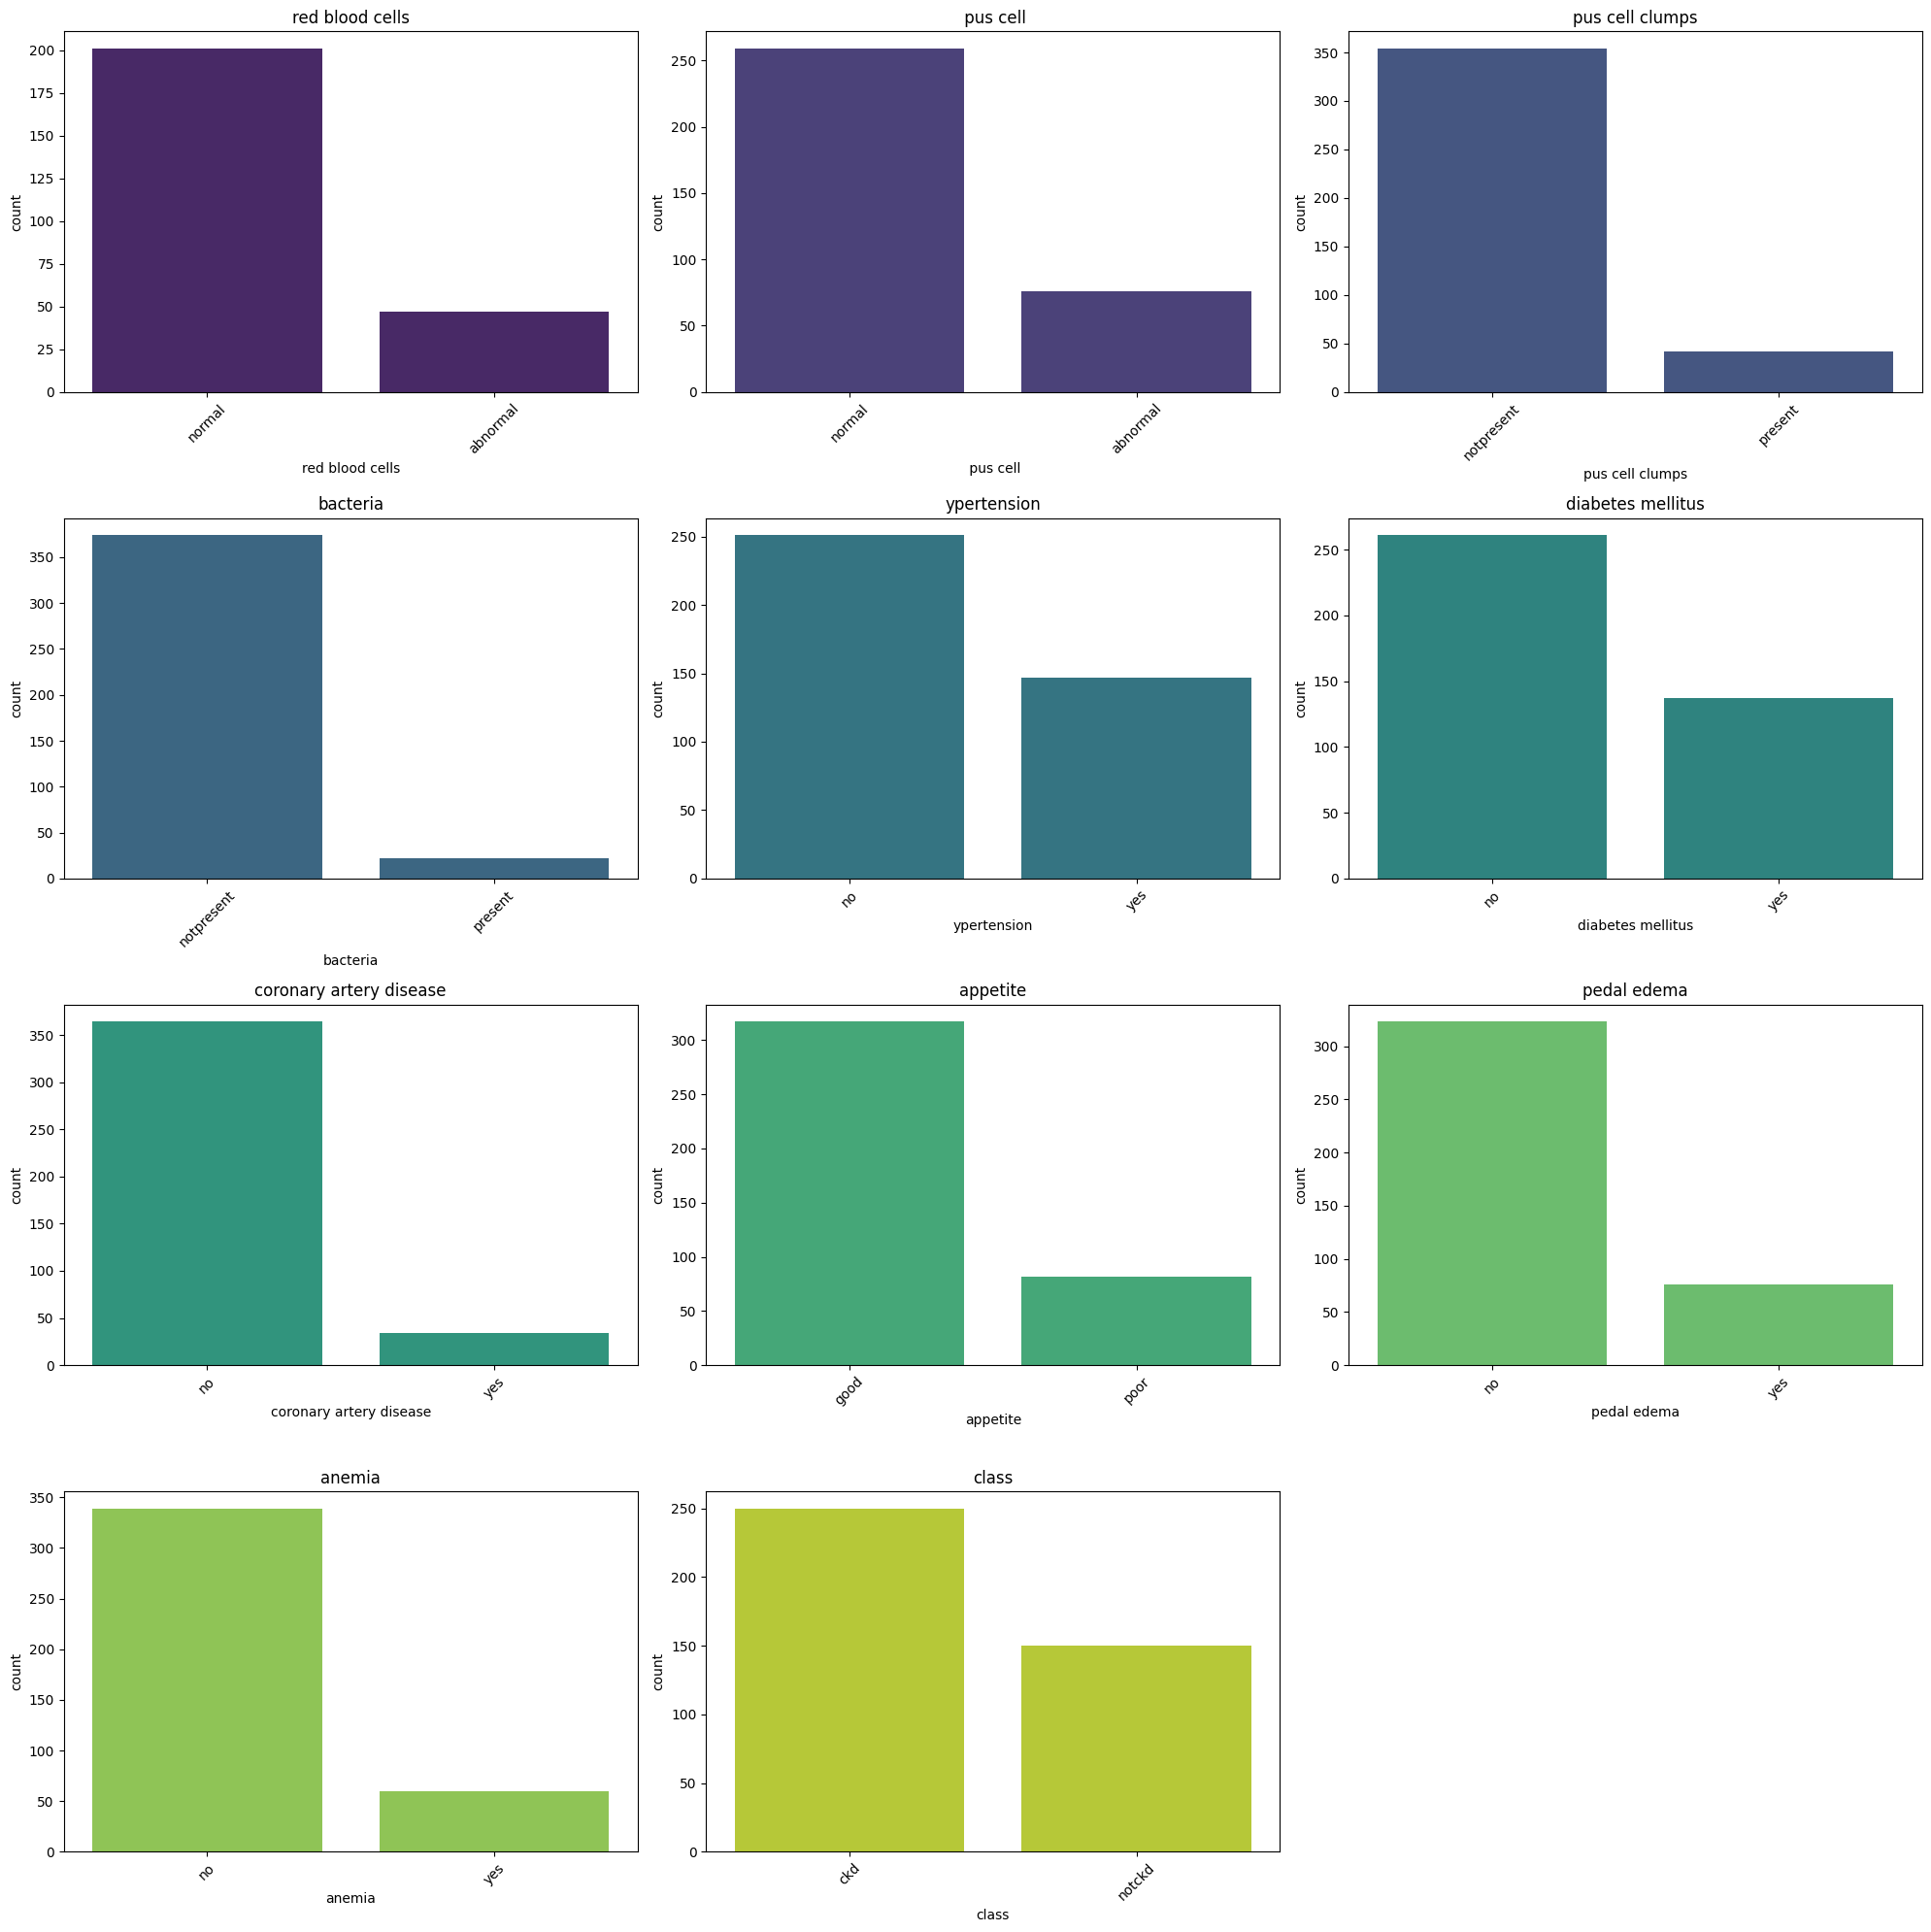

In [84]:
n = len(cat_col)
cols = 3
rows = (n // cols) + (n % cols > 0)

colors = sns.color_palette('viridis', n_colors=n)

plt.figure(figsize=(20, 5 * rows))

for i, feature in enumerate(cat_col):
    plt.subplot(rows, cols, i + 1)

    sns.countplot(
        x=df[feature],
        order=df[feature].value_counts().index,
        color=colors[i]
    )

    plt.title(feature)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [85]:
#A few features have imbalanced categories. Stratified folds will be necessary while cross validation.

Text(0.5, 1.0, 'target Class')

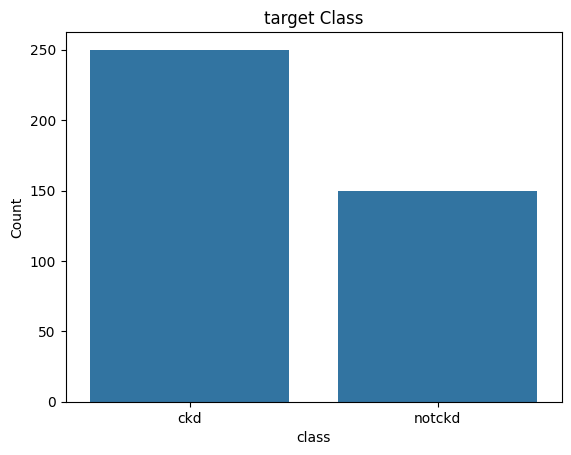

In [86]:
sns.countplot(x='class',data=df)
plt.xlabel("class")
plt.ylabel("Count")
plt.title("target Class")

<Axes: >

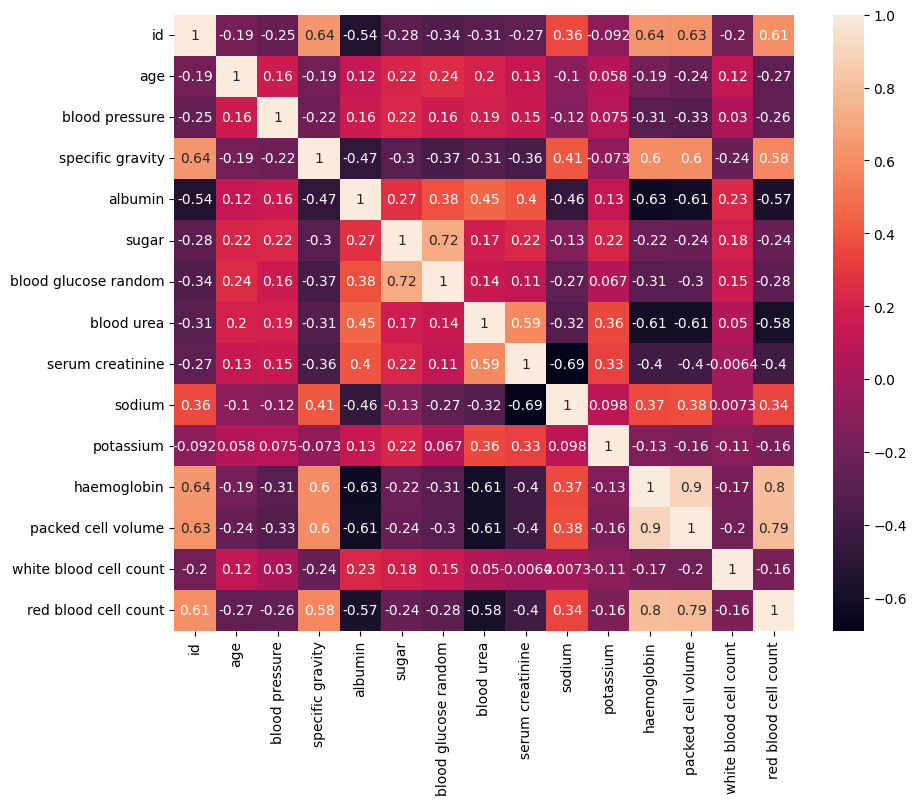

In [87]:
plt.figure(figsize=(10,8))
corr_df = df.corr(numeric_only=True)
sns.heatmap(corr_df,annot=True)

In [88]:
#Positive Correlation:

#Specific gravity -> Red blood cell count, Packed cell volume and Hemoglobin
#Sugar -> Blood glucose random
#Blood Urea -> Serum creatinine
#Hemoglobin -> Red Blood cell count <- packed cell volume


#Negative Correlation:
#Albumin, Blood urea -> Red blood cell count, packed cell volume, Hemoglobin
#Serum creatinine -> Sodium

In [89]:
df.groupby(['red blood cells','class'])['red blood cell count'].agg(['count','mean','median','min','max'])

count      mean  median  min  max
red blood cells class                                    
abnormal        ckd        25  3.832000     3.7  2.5  5.6
normal          ckd        40  3.782500     3.8  2.1  8.0
                notckd    134  5.368657     5.3  4.4  6.5

In [90]:
import plotly.express as px

In [91]:
px.violin(df,y='red blood cell count',x='class', color='class')

In [92]:
px.scatter(df,'haemoglobin','packed cell volume')

In [100]:
def violin(col):
    fig = px.violin(df, y=col, x="class", color="class", box=True)
    return fig.show()

def scatters(col1,col2):
    fig = px.scatter(df, x=col1, y=col2, color="class")
    return fig.show()

In [96]:
def kde_plot(feature):
    grid = sns.FacetGrid(df, hue="class",aspect=2)
    grid.map(sns.kdeplot, feature)
    grid.add_legend()

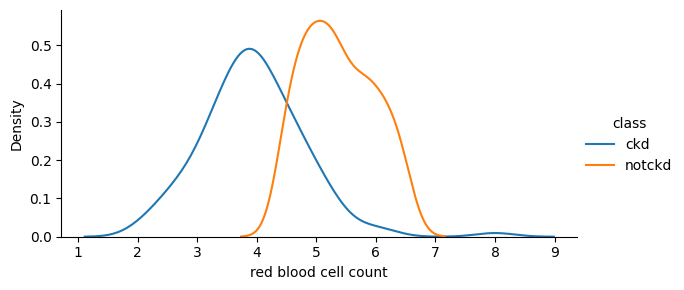

In [97]:
kde_plot('red blood cell count')

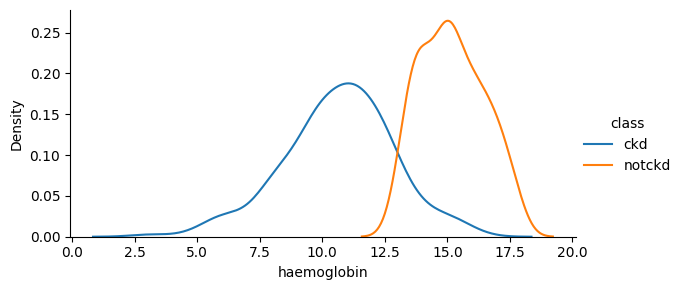

In [98]:
kde_plot('haemoglobin')

In [105]:
scatters('red blood cell count', 'packed cell volume')

In [106]:
scatters('red blood cell count', 'haemoglobin')

In [107]:
scatters('haemoglobin','packed cell volume')

In [ ]:
 1.RBC count range ~2 to <4.5 and Hemoglobin between 3 to <13 are mostly classified as positive for chronic kidney
    disease(i.e ckd).
    2.RBC count range >4.5 to ~6.1 and Hemoglobin between >13 to 17.8 are classified as negative for chronic kidney
    disease(i.e nockd).

In [101]:
violin('red blood cell count')

In [111]:
violin('packed cell volume')

In [109]:
scatters('red blood cell count','albumin')

In [ ]:
Clearly, albumin levels of above 0 affect ckd largely

In [112]:
scatters('packed cell volume','blood urea')

In [ ]:
Packed cell volume >= 40 largely affects to be non ckd



In [115]:
fig = px.bar(df, x="specific gravity", y="packed cell volume",
             color='class', barmode='group',
             height=400)
fig.show()

In [ ]:
Clearly, specific gravity >=1.02 affects non ckd

In [116]:
df.head()

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,ypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [117]:
df.isna().sum().sort_values(ascending=False)

,0
red blood cells,152
red blood cell count,131
white blood cell count,106
potassium,88
sodium,87
packed cell volume,71
pus cell,65
haemoglobin,52
sugar,49
specific gravity,47


In [118]:
cat_col

['red blood cells',
 ' pus cell',
 'pus cell clumps',
 'bacteria',
 'ypertension',
 'diabetes mellitus',
 'coronary artery disease',
 'appetite',
 'pedal edema',
 'anemia',
 'class']

<Axes: xlabel='count', ylabel='red blood cells'>

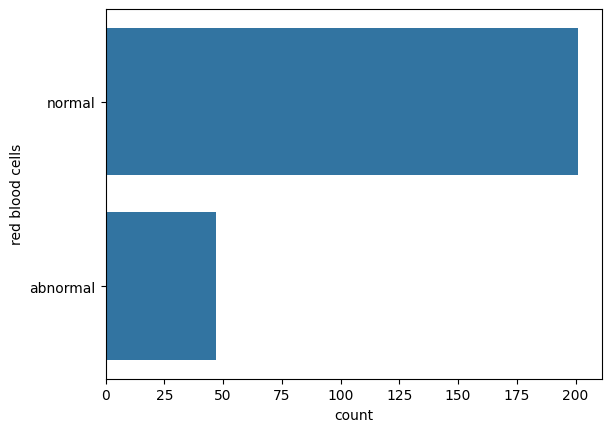

In [120]:
sns.countplot(df['red blood cells'])

In [121]:
data=df.copy()

In [ ]:
### filling missing with Random value

In [123]:
data['red blood cells'].isnull().sum()

np.int64(152)

In [125]:
data['red blood cells'].dropna().sample()

,red blood cells
364,normal


In [127]:
random_sample=data['red blood cells'].dropna().sample(data['red blood cells'].isnull().sum())
random_sample

,red blood cells
248,abnormal
385,normal
249,normal
195,abnormal
263,normal
...,...
331,normal
221,normal
345,normal
355,normal


In [128]:
random_sample.index

Index([248, 385, 249, 195, 263, 159, 306, 377, 281, 157,
       ...
       367,  56,  14, 328, 369, 331, 221, 345, 355, 265],
      dtype='int64', length=152)

In [130]:
data[data['red blood cells'].isnull()].index

Index([  0,   1,   5,   6,  10,  12,  13,  15,  16,  17,
       ...
       245, 268, 280, 290, 295, 309, 322, 349, 350, 381],
      dtype='int64', length=152)

In [131]:
random_sample.index=data[data['red blood cells'].isnull()].index

In [132]:
random_sample.index

Index([  0,   1,   5,   6,  10,  12,  13,  15,  16,  17,
       ...
       245, 268, 280, 290, 295, 309, 322, 349, 350, 381],
      dtype='int64', length=152)

In [133]:
random_sample

,red blood cells
0,abnormal
1,normal
5,normal
6,abnormal
10,normal
...,...
309,normal
322,normal
349,normal
350,normal


In [135]:
data.loc[data['red blood cells'].isnull(),'red blood cells']=random_sample

In [136]:
data.head()

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,ypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,abnormal,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


<Axes: xlabel='count', ylabel='red blood cells'>

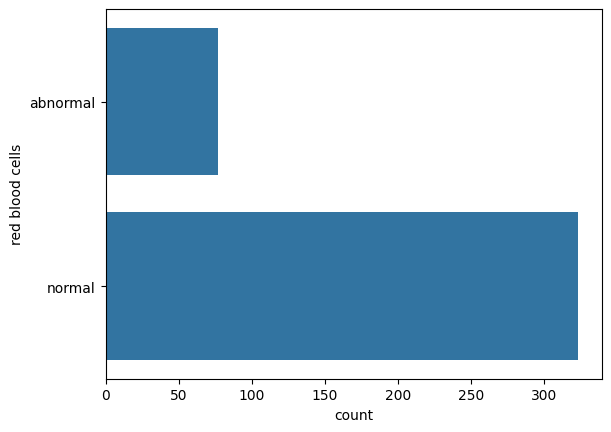

In [138]:
sns.countplot(data['red blood cells'])

In [139]:
data['red blood cells'].value_counts()/len(data)

,count
red blood cells,
normal,0.8075
abnormal,0.1925


In [142]:
### lets create a function so that I can easily do it for all features
def Random_value_imputation(feature):
    random_sample=data[feature].dropna().sample(data[feature].isnull().sum())
    random_sample.index=data[data[feature].isnull()].index
    data.loc[data[feature].isnull(),feature]=random_sample



In [146]:
cat_col

['red blood cells',
 ' pus cell',
 'pus cell clumps',
 'bacteria',
 'ypertension',
 'diabetes mellitus',
 'coronary artery disease',
 'appetite',
 'pedal edema',
 'anemia',
 'class']

In [147]:
Random_value_imputation(' pus cell')
Random_value_imputation('red blood cells')

In [149]:
mode=data['pus cell clumps'].mode()[0]
mode

'notpresent'

In [150]:

data['pus cell clumps']=data['pus cell clumps'].fillna(mode)

In [151]:
def impute_mode(feature):
    mode=data[feature].mode()[0]
    data[feature]=data[feature].fillna(mode)

In [152]:
for col in cat_col:
    impute_mode(col)

In [153]:
data[cat_col].isnull().sum()

,0
red blood cells,0
pus cell,0
pus cell clumps,0
bacteria,0
ypertension,0
diabetes mellitus,0
coronary artery disease,0
appetite,0
pedal edema,0
anemia,0


In [154]:
data[num_col].isnull().sum()

,0
id,0
age,9
blood pressure,12
specific gravity,47
albumin,46
sugar,49
blood glucose random,44
blood urea,19
serum creatinine,17
sodium,87


In [155]:
for col in num_col:
    Random_value_imputation(col)

In [156]:
data[num_col].isnull().sum()

,0
id,0
age,0
blood pressure,0
specific gravity,0
albumin,0
sugar,0
blood glucose random,0
blood urea,0
serum creatinine,0
sodium,0


In [157]:
for col in cat_col:
    print('{} has {} categories'.format(col, data[col].nunique()))


red blood cells has 2 categories
 pus cell has 2 categories
pus cell clumps has 2 categories
bacteria has 2 categories
ypertension has 2 categories
diabetes mellitus has 2 categories
coronary artery disease has 2 categories
appetite has 2 categories
pedal edema has 2 categories
anemia has 2 categories
class has 2 categories


In [ ]:
#### as we have just 2 categories in each feature then we can consider Label Encoder as it will not cause Curse of Dimensionality

In [158]:
from sklearn.preprocessing import LabelEncoder

In [159]:
le = LabelEncoder()

In [160]:
for col in cat_col:
    data[col]=le.fit_transform(data[col])

In [161]:
data.head()

,id,age,blood pressure,specific gravity,albumin,sugar,red blood cells,pus cell,pus cell clumps,bacteria,...,packed cell volume,white blood cell count,red blood cell count,ypertension,diabetes mellitus,coronary artery disease,appetite,pedal edema,anemia,class
0,0,48.0,80.0,1.020,1.0,0.0,0,1,0,0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,...,38.0,6000.0,5.3,0,0,0,0,0,0,0
2,2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,...,31.0,7500.0,4.1,0,1,0,1,0,1,0
3,3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0
